# Notebook 04 — Baseline Models

**Project:** Boston Marathon BQ Predictor  
**Author:** Gian Marco  
**Date:** April 2026

## Objectives

1. Establish a reference baseline using DummyClassifier (two strategies)
2. Train a linear baseline model (LogisticRegression) with StandardScaler
3. Train a simple non-linear baseline (DecisionTree) with anti-overfitting controls
4. Compare all models using cross-validation (5-fold) within the training set
5. Report F1-score (positive class), PR-AUC, and ROC-AUC
6. Identify the best baseline model to benchmark against advanced models in Notebook 05

## Fundamental Rule

The `test_features.csv` dataset is NOT used in this notebook. All comparisons are performed via cross-validation on `train_features.csv`. The test set is reserved for Notebook 07.

## Evaluation Metric

**F1-score of the positive class (BQ=1).** PR-AUC and ROC-AUC are also reported but are not used to rank models.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DATA_DIR = Path('../data/processed')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Setup ready')

Setup ready


---
## 1. Load data and split into X / y

In [2]:
TRAIN_DIR = Path('../data/train')
train = pd.read_csv(TRAIN_DIR / 'train_features.csv')

X = train.drop(columns=['es_BQ'])
y = train['es_BQ']

# Drop Year as a feature (see DECISIONS.md Decision 3)
if 'Year' in X.columns:
    X = X.drop(columns=['Year'])

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'Features: {X.columns.tolist()}')

print(f'\nBQ rate in train: {y.mean()*100:.2f}%')
print(f'Imbalance ratio: 1:{(y==0).sum() / (y==1).sum():.2f}')

Shape X: (225356, 22)
Shape y: (225356,)
Features: ['Age', 'Is_Home_Country', 'Race_Category_enc', 'Race_te', 'Age_Squared', 'Gender_M', 'Country_AU', 'Country_BR', 'Country_CA', 'Country_DE', 'Country_ES', 'Country_FR', 'Country_GB', 'Country_IE', 'Country_IT', 'Country_JP', 'Country_MX', 'Country_NL', 'Country_Other', 'Country_PL', 'Country_TH', 'Country_US']

BQ rate in train: 13.45%
Imbalance ratio: 1:6.43


---
## 2. Cross-Validation Setup

We use `StratifiedKFold` with 5 folds. Stratification ensures that each fold preserves the 87/13 target distribution, preventing folds with too few BQ cases.

We define a `scorers` dictionary with the three evaluation metrics so that `cross_validate` returns all of them in a single run.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'f1_pos': 'f1',
    'precision_pos': 'precision',
    'recall_pos': 'recall',
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc',
}

print('CV configured: StratifiedKFold with 5 folds')
print(f'Metrics to compute: {list(scoring.keys())}')

CV configured: StratifiedKFold with 5 folds
Metrics to compute: ['f1_pos', 'precision_pos', 'recall_pos', 'pr_auc', 'roc_auc']


---
## 3. Helper Function to Summarize CV Results

In [4]:
def summarize_cv(cv_results, model_name):
    summary = {'model': model_name}
    for metric in scoring.keys():
        key = f'test_{metric}'
        summary[f'{metric}_mean'] = cv_results[key].mean()
        summary[f'{metric}_std'] = cv_results[key].std()
    summary['fit_time_mean'] = cv_results['fit_time'].mean()
    return summary

results = []
print('Helper ready')

Helper ready


---
## 4. Dummy 1 — Most Frequent

This model always predicts the majority class (no-BQ). It highlights why accuracy is not a useful metric in this problem.

In [5]:
dummy_mf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
cv_out = cross_validate(dummy_mf, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'Dummy (most_frequent)')
results.append(summary)

print(f"F1 (positive class):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:            {summary['precision_pos_mean']:.4f}")
print(f"Recall:               {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:               {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:              {summary['roc_auc_mean']:.4f}")

print(f"\nInterpretation: F1=0 because the model never predicts BQ=1. This shows why accuracy is misleading.")

F1 (positive class):  0.0000 ± 0.0000
Precision:            0.0000
Recall:               0.0000
PR-AUC:               0.1345
ROC-AUC:              0.5000

Interpretation: F1=0 because the model never predicts BQ=1. This shows why accuracy is misleading.


---
## 5. Dummy 2 — Stratified

This model makes random predictions while preserving the original class distribution (87/13). It represents a “random baseline informed by class imbalance.”

In [6]:
dummy_strat = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
cv_out = cross_validate(dummy_strat, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'Dummy (stratified)')
results.append(summary)

print(f"F1 (positive class):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"PR-AUC:               {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:              {summary['roc_auc_mean']:.4f}")

print(f"\nInterpretation: F1 ≈ {y.mean():.3f} (base rate). ROC-AUC ≈ 0.5 because the model is essentially random.")

F1 (positive class):  0.1378 ± 0.0001
PR-AUC:               0.1350
ROC-AUC:              0.5020

Interpretation: F1 ≈ 0.135 (base rate). ROC-AUC ≈ 0.5 because the model is essentially random.


---
## 6. Logistic Regression with StandardScaler

Pipeline = StandardScaler + LogisticRegression to avoid leakage from scaling during cross-validation.

Configuration:
- `max_iter=1000` — ensure convergence  
- No `class_weight='balanced'` yet — this will be tested in Notebook 06  

In [7]:
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
])

cv_out = cross_validate(logreg_pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'LogisticRegression')
results.append(summary)

print(f"F1 (positive class):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:            {summary['precision_pos_mean']:.4f}")
print(f"Recall:               {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:               {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:              {summary['roc_auc_mean']:.4f}")
print(f"Average fit time:     {summary['fit_time_mean']:.2f}s")

F1 (positive class):  0.1666 ± 0.0062
Precision:            0.5488
Recall:               0.0982
PR-AUC:               0.3276
ROC-AUC:              0.7286
Average fit time:     0.52s


---
## 7. Decision Tree with Anti-Overfitting Controls

- `max_depth=8`  
- `min_samples_leaf=50`  

In [8]:
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    random_state=RANDOM_STATE,
)

cv_out = cross_validate(dt, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'DecisionTree (depth=8, leaf=50)')
results.append(summary)

print(f"F1 (positive class):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:            {summary['precision_pos_mean']:.4f}")
print(f"Recall:               {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:               {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:              {summary['roc_auc_mean']:.4f}")
print(f"Average fit time:     {summary['fit_time_mean']:.2f}s")

F1 (positive class):  0.1506 ± 0.0144
Precision:            0.5693
Recall:               0.0870
PR-AUC:               0.3263
ROC-AUC:              0.7316
Average fit time:     0.32s


---
## 8. Baseline Comparison Table

We consolidate the results of the four models into a single table to facilitate comparison and presentation (e.g., slides).

In [9]:
df_results = pd.DataFrame(results)

# Mean metric columns with clean formatting
metric_cols = ['f1_pos_mean', 'precision_pos_mean', 'recall_pos_mean', 'pr_auc_mean', 'roc_auc_mean']
display_df = df_results[['model'] + metric_cols + ['fit_time_mean']].copy()

# Rename columns for presentation
display_df.columns = ['Model', 'F1 (pos)', 'Precision', 'Recall', 'PR-AUC', 'ROC-AUC', 'Fit time (s)']

# Format numeric values
for col in ['F1 (pos)', 'Precision', 'Recall', 'PR-AUC', 'ROC-AUC']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')
display_df['Fit time (s)'] = display_df['Fit time (s)'].apply(lambda x: f'{x:.2f}')

# Sort by F1 descending
display_df = display_df.sort_values('F1 (pos)', ascending=False).reset_index(drop=True)

print('BASELINE RANKING (sorted by positive class F1)')
print('=' * 90)
print(display_df.to_string(index=False))

BASELINE RANKING (sorted by positive class F1)
                          Model F1 (pos) Precision Recall PR-AUC ROC-AUC Fit time (s)
             LogisticRegression   0.1666    0.5488 0.0982 0.3276  0.7286         0.52
DecisionTree (depth=8, leaf=50)   0.1506    0.5693 0.0870 0.3263  0.7316         0.32
             Dummy (stratified)   0.1378    0.1380 0.1376 0.1350  0.5020         0.04
          Dummy (most_frequent)   0.0000    0.0000 0.0000 0.1345  0.5000         0.08


---
## 9. Comparative Visualization

A grouped bar chart to quickly compare the relative performance of the four models across the three key metrics.

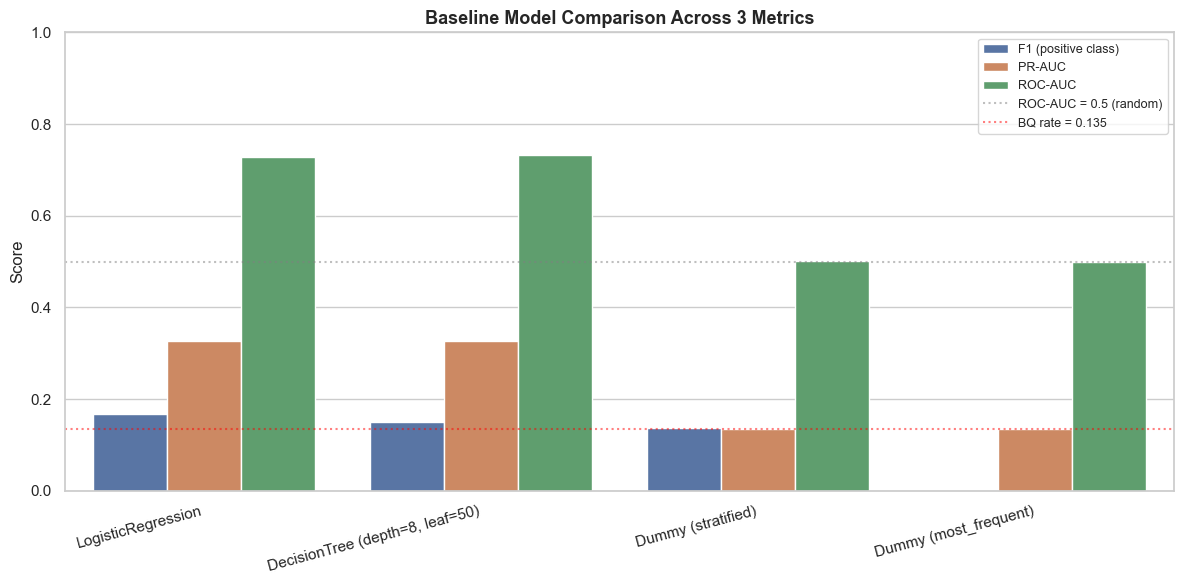

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Prepare data in long format for seaborn
plot_df = df_results[['model', 'f1_pos_mean', 'pr_auc_mean', 'roc_auc_mean']].copy()
plot_df = plot_df.melt(id_vars='model', var_name='metric', value_name='score')
plot_df['metric'] = plot_df['metric'].map({
    'f1_pos_mean': 'F1 (positive class)',
    'pr_auc_mean': 'PR-AUC',
    'roc_auc_mean': 'ROC-AUC',
})

# Fixed order for readability
model_order = df_results.sort_values('f1_pos_mean', ascending=False)['model'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x='model',
    y='score',
    hue='metric',
    order=model_order,
    palette='deep',
    ax=ax,
    edgecolor='white'
)

# Reference lines
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='ROC-AUC = 0.5 (random)')
ax.axhline(y.mean(), color='red', linestyle=':', alpha=0.5, label=f'BQ rate = {y.mean():.3f}')

ax.set_title('Baseline Model Comparison Across 3 Metrics', fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()

# Save for presentation
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / '08_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Save Consolidated Results

We save the results table as a CSV file to reuse it in Notebook 05 (comparison with advanced models) and in the final presentation.

In [11]:
df_results.to_csv(PROCESSED_DATA_DIR / 'baseline_results.csv', index=False)

print(f'Results saved to: {PROCESSED_DATA_DIR / "baseline_results.csv"}')

winner = df_results.sort_values("f1_pos_mean", ascending=False).iloc[0]["model"]
print(f'\nBest baseline model (by F1): {winner}')

Results saved to: ../data/processed/baseline_results.csv

Best baseline model (by F1): LogisticRegression


---
## 11. Final Interpretation and Conclusions (Notebook 04)

### Ranking by Positive-Class F1

1. **LogisticRegression** — F1 = 0.167 (baseline winner)  
2. **DecisionTree (depth=8, leaf=50)** — F1 = 0.151  
3. **Dummy (stratified)** — F1 = 0.138  
4. **Dummy (most_frequent)** — F1 = 0.000  

### Key Observations

**1. Real models barely outperform informed randomness.**  
Only ~3 F1 points above the stratified dummy. There is significant room for improvement.

**2. Accuracy is misleading.**  
The most_frequent dummy would achieve ~86.5% accuracy—better than any other model on that metric—without learning anything.  
This justifies the choice of F1 and PR-AUC as primary evaluation metrics.

**3. Large gap between precision and recall.**  
With a 0.5 threshold:
- When the model predicts BQ, it is correct ~55% of the time  
- But it only captures ~9% of actual BQ cases  

This is a classic symptom of class imbalance combined with a conservative threshold.  
Strategies to address this in upcoming notebooks:
- `class_weight='balanced'` (Notebook 06)  
- SMOTE oversampling (Notebook 06)  
- Threshold tuning (Notebook 07)  

**4. Logistic Regression outperforms Decision Tree in this baseline.**  
This may seem counterintuitive but is explainable:  
- The anti-overfitting constraints on the tree (`max_depth=8`) limit its ability to capture complex interactions  
- `Age_Squared` allows Logistic Regression to model some non-linearity  

Non-linear models are expected to outperform once constraints are relaxed in Notebook 05 (Random Forest, XGBoost).

**5. ROC-AUC ~0.73 for both real models.**  
This is a more optimistic metric than F1 but less informative under class imbalance.  
Both metrics will be reported in the final presentation.